In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from numba import njit

In [2]:
L = 10
temp = np.linspace(2.269, 5, 10)
T = 5.0

In [13]:
all_states = []
all_energies = []
all_magnetizations = []

temp = [2.269]
a, b = 19645, 20535
a, b = 0, -1
for T in temp:
    loaded_energy = np.load(os.path.join("data", f"L_{L}", f"T_{T}", "energy.npy"))
    loaded_magnetization = np.load(os.path.join("data", f"L_{L}", f"T_{T}", "magnitization.npy"))
    loaded_states = np.load(os.path.join("data", f"L_{L}", f"T_{T}", "states.npy"))

    if T == temp[0]:
        all_states.append(loaded_states[a:b])
        all_energies.append(loaded_energy[a:b])
        all_magnetizations.append(loaded_magnetization[a:b])

    else:
        all_states.append(loaded_states[15000:25000])
        all_energies.append(loaded_energy[15000:25000])
        all_magnetizations.append(loaded_magnetization[15000:25000])

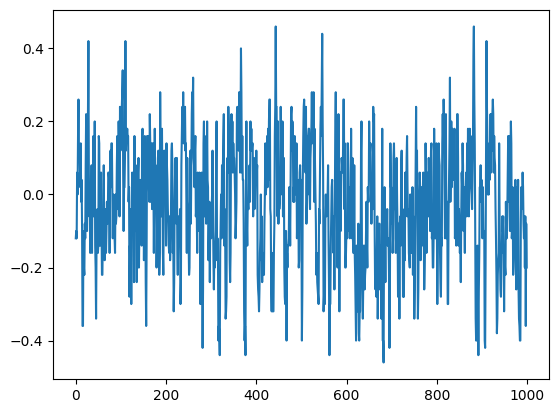

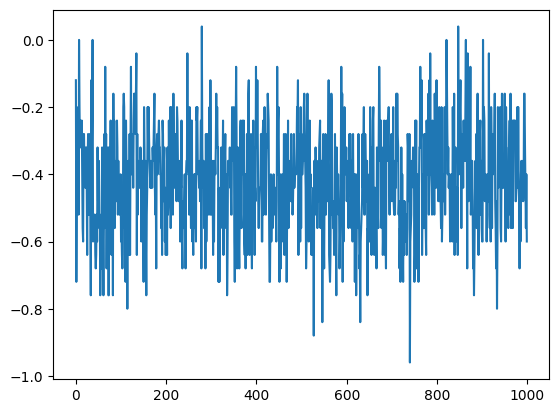

In [4]:
plt.plot(loaded_magnetization[0:1000])
plt.show()
plt.plot(loaded_energy[0:1000])
plt.show()

# One need not to remove the states, because they introduces the significant bias. 

In [5]:
def remove_identical_states(states):
    #removing the states which are the same, because there. 
    #hamming distance is almost equal.
    unique_states = []
    for i, state in enumerate(states):
        the_same_value = False
        for unique_state in unique_states:
            if np.array_equal(state, unique_state):
                the_same_value = True
                break
        if not the_same_value:
            unique_states.append(state)

    return np.array(unique_states)

In [16]:
def remove_identical_states(states):
    unique_hashes = set()
    unique_states = []

    for state in states:
        state_hash = hash(state.tobytes())
        if state_hash not in unique_hashes:
            unique_hashes.add(state_hash)
            unique_states.append(state)

    return np.array(unique_states)

unique_states = remove_identical_states(loaded_states)
len(unique_states), len(loaded_states)

(29114, 30000)

In [7]:
#checking for each temperatures
A = []
B = []
new_loaded_states = []
for i in range(len(all_states)):
    a = remove_identical_states(all_states[i])
    a_len = len(a)
    b_len = len(all_states[i])
    A.append(a_len)
    B.append(b_len)
    new_loaded_states.append(a)

A, B = np.array(A), np.array(B)
A, B

(array([14681, 10000, 15000, 15000, 15000, 15000, 15000, 15000, 15000,
        15000]),
 array([15000, 10000, 15000, 15000, 15000, 15000, 15000, 15000, 15000,
        15000]))

# Hamming Distance

In [8]:
@njit
def hamming_distances(states):
    #Calculating the hamming distances between the states
    #here, we again make sure that no 2 states are same

    num_states, L, _ = states.shape
    distances = np.zeros((num_states, num_states - 1))
    for i in range(num_states):
        ref_state = states[i]
        index = 0
        for j in range(num_states):
            if i != j:
                diff = np.abs(ref_state - states[j])
                distances[i, index] = np.sum(diff)
                index += 1
    return distances

In [9]:
#dist1 = hamming_distances(all_states[-1])
#dist2 = hamming_distances(new_loaded_states[-2])
#dist3 = hamming_distances(all_states[-3])
#dist4 = hamming_distances(new_loaded_states[-4])
#dist5 = hamming_distances(new_loaded_states[-5])
#dist6 = hamming_distances(new_loaded_states[-6])
#dist7 = hamming_distances(all_states[-7])
#dist8 = hamming_distances(new_loaded_states[-8])
#dist9 = hamming_distances(new_loaded_states[-9])
#dist10 = hamming_distances(all_states[0])

#final_distances = [dist1, dist2, dist3, dist4, dist5, dist6, dist7, dist8, dist9, dist10]
#output_dir = "Hamming_Distances_n"
#os.makedirs(output_dir, exist_ok=True)


#for array, T in zip(final_distances, temp):
 #   filename = f"hamming_dist_T_{T}.npy"
 #   filepath = os.path.join(output_dir, filename)
 #   np.save(filepath, array)
 #   print(f"Saved: {filepath}")

In [10]:
#final_distances = [dist1, dist2, dist3, dist4, dist5, dist6, dist7, dist8, dist9, dist10]
#final_distances = [dist10, dist7, dist3, dist1]
#output_dir = "Hamming_Distances_n"
#os.makedirs(output_dir, exist_ok=True)
#temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]


#for array, T in zip(final_distances, temp_n):
#    filename = f"hamming_dist_T_{T}.npy"
#    filepath = os.path.join(output_dir, filename)
#    np.save(filepath, array)
#    print(f"Saved: {filepath}")

# Calling Haming distances for all temperatures

In [11]:
temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]

output_dir = "Hamming_Distances_n"
os.makedirs(output_dir, exist_ok=True)

loaded_distances = []
for T in temp_n:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [12]:
def min_dist(dist):
    new_dist = []
    min_index = []
    for i in range(len(dist)):
        new_dist.append(np.min(dist[i]))
        min_index.append(np.argmin(dist[i]))
    return np.array(new_dist) , np.array(min_index)

In [29]:
new_distances = []
new_indices = []
for dist in loaded_distances:
    new_dist, new_index = min_dist(dist)
    new_distances.append(new_dist)
    new_indices.append(new_index)

In [30]:
new_distances

[array([22., 24., 22., ...,  4.,  4.,  2.]),
 array([40., 40., 48., ..., 48., 34., 34.]),
 array([62., 58., 58., ..., 60., 60., 56.]),
 array([58., 60., 62., ..., 60., 62., 52.])]

In [31]:
new_distance = []
for i in range(len(temp_n)):
    new_distance.append(np.savetxt(f"Hamming_Distances_n/new_distances_T_{temp_n[i]}.txt", new_distances[i]))

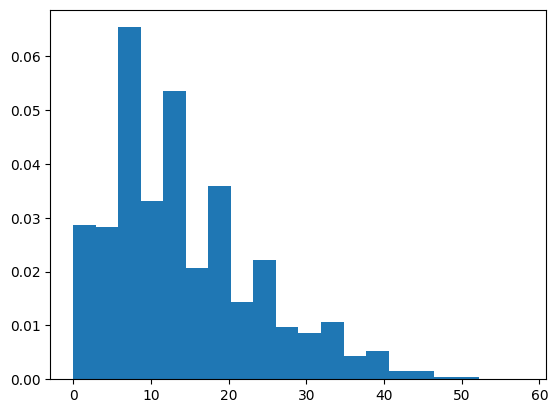

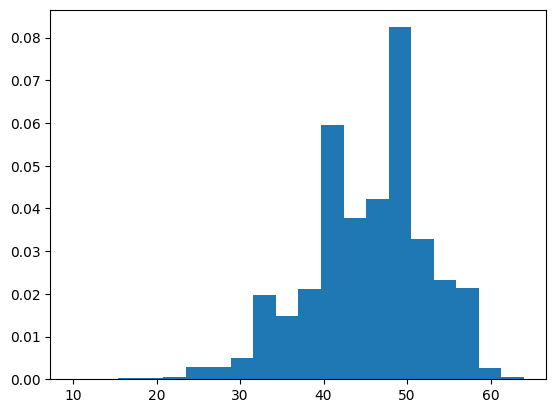

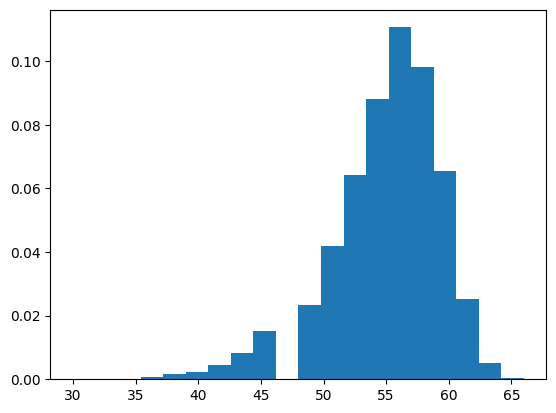

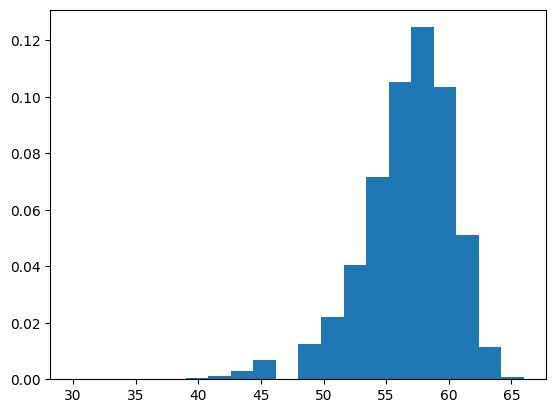

In [33]:
plt.hist(new_distances[0], bins=20, density = True)
plt.show()
plt.hist(new_distances[1], bins=20, density = True)
plt.show()
plt.hist(new_distances[2], bins=20, density = True)
plt.show()
plt.hist(new_distances[3], bins=20, density = True)
plt.show()

In [34]:
new_distances = []
for i in range(len(temp_n)):
    new_distances.append(np.loadtxt(f"Hamming_Distances_n/new_distances_T_{temp_n[i]}.txt"))

In [37]:
dist = new_distances[0]
len(dist)

15000

Text(0.5, 0, 'T')

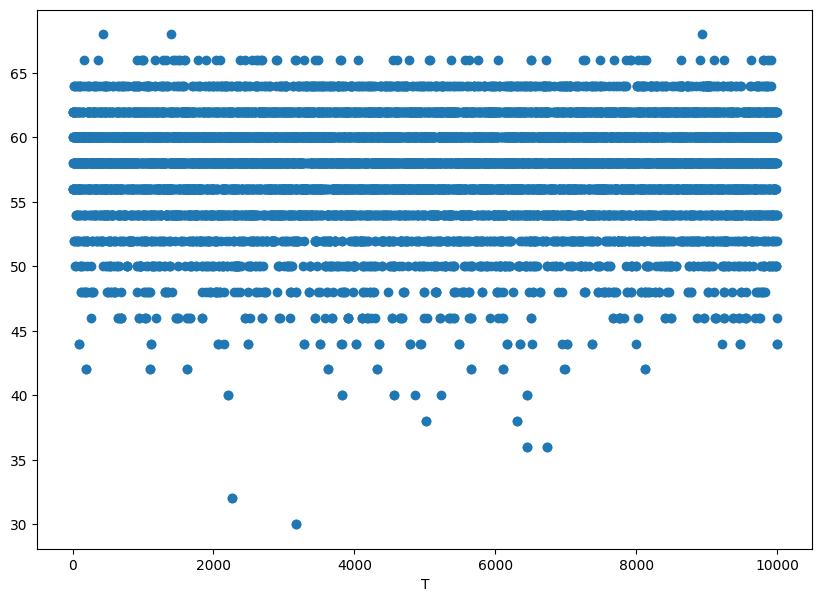

In [51]:
plt.figure(figsize = (10, 7))
plt.plot(new_distances[0], 'o')
plt.xlabel("T")